#### What is an lmplot?
An lmplot (Linear Model Plot) is a function that creates a grid of regression plots. It combines the functionality of a regplot (plotting a scatter plot with a linear regression line) with the power of a FacetGrid (creating multiple plots based on the levels of a categorical variable).

Its primary purpose is to help you visualize how the linear relationship between two numerical variables changes depending on the values of one or more other categorical variables.

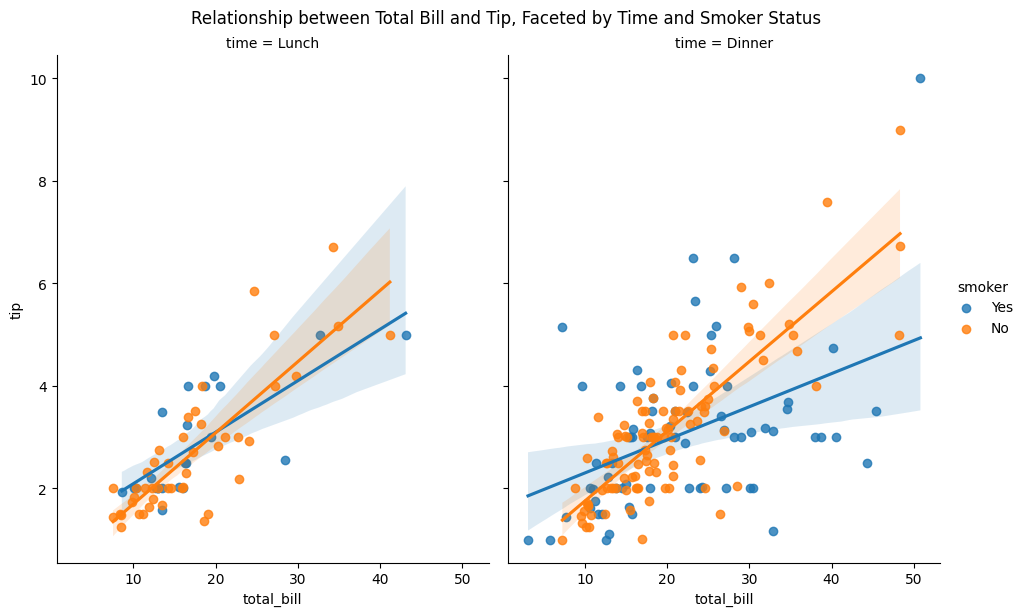

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sample Data
# Load the built-in 'tips' dataset from Seaborn
df = sns.load_dataset('tips')

# 2. Sample Code for the Plot

# lmplot is a "figure-level" function, so we don't typically create a figure beforehand.
# It manages its own figure.

# x, y: The two numerical variables
# data: The DataFrame
# hue: Creates different colored regression lines on the same plot for each category.
# col: Creates separate plots (columns) for each category.
# row: Creates separate plots (rows) for each category.
sns.lmplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='smoker', # Show separate lines for smokers and non-smokers
    col='time',   # Create separate columns for Lunch and Dinner
    height=6,     # Set the height of each individual plot
    aspect=0.8    # Control the aspect ratio of each plot
)

# Use plt.suptitle() for a title on a figure-level plot
plt.suptitle('Relationship between Total Bill and Tip, Faceted by Time and Smoker Status', y=1.02)
plt.show()

#### What Type of Information It Provides
An lmplot provides all the information of a regplot but allows you to easily investigate more complex questions.

Conditional Relationships: This is its key strength. It answers questions like, "What is the relationship between X and Y, for each level of Z?" In our example, we can see the relationship between bill and tip separately for smokers and non-smokers, and we can see how that entire picture changes between Lunch and Dinner.

Interaction Effects: It is the best tool for visualizing interaction effects.

By looking at the hue lines, you can see if the slopes are different. In our plot for "Dinner", the red line (smokers) appears slightly steeper than the blue line (non-smokers), suggesting that for dinner, smokers might tip more aggressively as the bill increases.
By comparing the plots in the "Lunch" and "Dinner" columns, you can see if the overall pattern is consistent across different times.
Robustness of a Trend: It helps you check if a trend you observed in the overall data holds true for different subgroups. A strong positive correlation in the whole dataset might disappear or even reverse within a specific subset.



#### Scenarios for Using an lmplot
1. During Exploratory Data Analysis (EDA)
To Investigate Interactions: This is its primary use case. Whenever you suspect that the relationship between two variables might be influenced by a third (or fourth) categorical variable, lmplot is the perfect tool.
Example: sns.lmplot(data=df, x='age', y='income', hue='gender', col='education_level'). This would create a grid of plots showing the age-income relationship for men and women separately, for each level of education.
To Systematically Explore Subgroups: It provides a structured way to break down your data and check for conditional patterns without having to manually filter and plot each subgroup yourself.
2. Communicating Complex Findings
Telling a Nuanced Story: An lmplot is excellent for presenting a more sophisticated finding than a simple correlation. It allows you to visually demonstrate that "the relationship between X and Y is not simple; it depends on Z."

#### lmplot vs. regplot: The Key Differences

| Feature | lmplot | regplot |
| :-- | :-- | :-- |
| Function Type | Figure-level (creates its own figure and grid) | Axes-level (draws on a specific, pre-existing subplot/axes) |
| Primary Use | Visualizing relationships across multiple subsets of data. | Drawing a single regression plot on a specific graph. |
| Key Parameters | Uses hue, col, and row to create facets. | Does not accept col or row. |
| Flexibility | Less flexible for combining with other plot types in a complex figure. | More flexible; can be easily added as one component of a larger, custom figure. |
| Data Input | Requires data to be in a "long-form" tidy DataFrame. | Can accept NumPy arrays or pandas Series directly for x and y. |


Rule of Thumb:

- If you just want one regression plot on your graph, use regplot.
- If you want to see how a relationship changes across different categories by creating multiple plots in a grid, use lmplot.
